<a href="https://colab.research.google.com/github/aimalqasi24-dotcom/ml-lab/blob/main/Health_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-dataset
--- MODEL ACCURACY COMPARISON ---
SVM Train Accuracy:         0.8958
SVM Test Accuracy:          0.8377
Decision Tree Train Acc:   0.9055
Decision Tree Test Acc:    0.8377

--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       100
           1       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       100
           1       0.78      0.74      0.76        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154

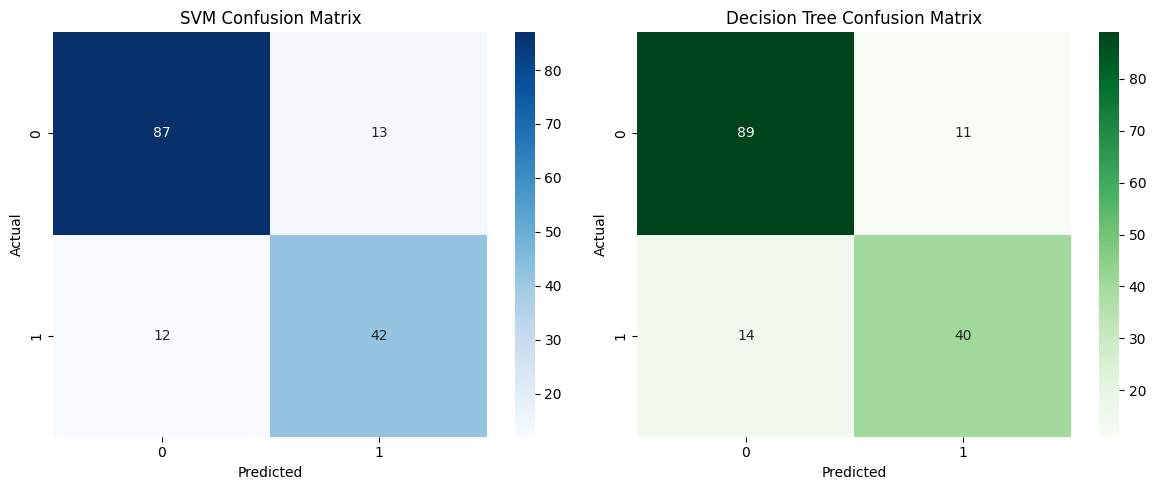

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print("Path to dataset files:", path)

# Roll No: [ AI-034]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Load the dataset from the downloaded path
df = pd.read_csv(os.path.join(path, "diabetes.csv"))

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]


for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())


X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("--- MODEL ACCURACY COMPARISON ---")
print(
    f"SVM Train Accuracy:         {accuracy_score(y_train, svm_model.predict(X_train_scaled)):.4f}"
)
print(
    f"SVM Test Accuracy:          {accuracy_score(y_test, svm_model.predict(X_test_scaled)):.4f}"
)
print(
    f"Decision Tree Train Acc:   {accuracy_score(y_train, dt_model.predict(X_train_scaled)):.4f}"
)
print(
    f"Decision Tree Test Acc:    {accuracy_score(y_test, dt_model.predict(X_test_scaled)):.4f}\n"
)


svm_preds = svm_model.predict(X_test_scaled)
dt_preds = dt_model.predict(X_test_scaled)

print("--- SVM Classification Report ---")
print(classification_report(y_test, svm_preds))

print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_preds))



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    confusion_matrix(y_test, svm_preds),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("SVM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, dt_preds),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
)
axes[1].set_title("Decision Tree Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()